In [1]:
%load_ext autoreload
%autoreload 2

In [179]:
import warnings
import pandas as pd
import yfinance as yf
import time
from helpers import filter_daily_volume, drop_nan_days, get_all_us_tickers, get_data, filter_tickers
import numpy as np
import matplotlib.pyplot as plt
from TradingSim import TradingSim

In [3]:
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", module="yfinance")

In [ ]:
tickers = get_all_us_tickers()

In [ ]:
# def get_data(tickers_list, period="max", interval="1d"):
# 	"""
# 	Divides the tickers_list into batches so it'll download each batch sepertly then combines into a full dataset
# 	tickers_list - list of tickers
# 	periood - String, Valid periods: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
# 	interval - String, Valid intervals: 1m, 2m, 5m, 15m, 30m, 60m, 90m, 1h, 1d, 5d, 1wk, 1mo, 3mo Intraday data cannot extend last 60 days 
# 	"""
# 	batches = []
# 	batches_size = 200
# 	for i in range(0, len(tickers_list), batches_size):
# 		batches.append(tickers_list[i: i+batches_size])
# 	print(batches)
# 	res = []
# 	i = 0
# 	# yf.download(tickers_list, period=period, interval=interval, group_by='columns')
# 	for batch in batches:
# 		print(f"Batch {i}/{len(batches)}")
# 		i += 1
# 		while True:
# 			yf.shared._ERRORS = {}
# 			failed_tickers = []
# 			batch_res = yf.download(batch, period=period, interval=interval, group_by='column')
# 			errors = yf.shared._ERRORS
# 			for ticker in errors:
# 				if errors[ticker].startswith("YFRateLimitError"):
# 					failed_tickers.append(ticker)
# 			batch_res.drop(columns=failed_tickers, level=1, inplace=True)
# 			res.append(batch_res)
# 			if (len(failed_tickers) == 0):
# 				break
# 			timeout = 20
# 			batch = failed_tickers
# 			print(f"Too many requests: Sleeping {timeout} seconds")
# 			time.sleep(timeout)
# 	return pd.concat(res, axis=1)

In [4]:
def filter_column(df, column, threshold, above=False):
	"""
	df - DataFrame
	column - column we want to filter by
	threshold - int/float if above then we delete everything above threshold, else below
	above - Boolean - True to filter above, False otherwise
	"""
	if above:
		mask = df[df[column] > threshold]
	else:
		mask = df[df[column] < threshold]
	df.drop(mask.index, inplace=True)

In [ ]:
full_data = get_data(tickers, "max")

In [11]:
df = yf.download(["AAPL", "SNDK"], start="2024-01-01")

[*********************100%***********************]  2 of 2 completed


In [106]:
# df = data.copy()
tmp = pd.read_parquet("AllUSData-20100101-20260303.parquet")

In [160]:
full_df = tmp.copy()

In [115]:
df = full_df[full_df.index.year == 2010]

In [69]:
start_date = '2024-02-19'
end_date = '2025-02-19'
df = df[(df.index >= start_date) & (df.index <= end_date)]

In [116]:
# Calculate 30-day rolling percentage change for Close prices

# 1. Calculate all the rolling averages at once
rolling_data = df["Close"].pct_change().rolling(window=30).mean() * 100

# 2. Create the MultiIndex for the new columns mathematically
rolling_data.columns = pd.MultiIndex.from_product([["rollingChange"], rolling_data.columns])
# 3. Slap the two tables together side-by-side
df = df.join(rolling_data)

In [117]:
df = filter_daily_volume(df, 2000000, True)
df = drop_nan_days(df, "Close", 2)

In [118]:
stats_df = pd.DataFrame(index=df.columns.get_level_values(1).unique().tolist())

In [119]:
close = df["Close"]
pct_change = ((close.iloc[-1] - close.iloc[0]) / close.iloc[0]) * 100
daily_returns = close.pct_change()
volatility = daily_returns.std() * np.sqrt(252) * 100 
steady_score = pct_change / volatility

nan_days = close.isna()

stats_df["TotalReturn %"] = pct_change
stats_df["Volatility %"] = volatility
stats_df["SteadyScore"] = steady_score
stats_df["PositiveDays %"] = (daily_returns > 0).mean() * 100

# max drawdown - Distance between lowest and peak
rolling_max = close.cummax()
daily_drawdown = (close - rolling_max) / rolling_max  # Distance from peak
stats_df["MaxDrawdown %"] = daily_drawdown.min() * 100  # % distance from worst drop

sma_50 = df["Close"].rolling(window=50).mean().iloc[-1]
stats_df["DistFromSMA50 %"] = ((close.iloc[-1] / sma_50) - 1) * 100

median_vol_30d = df["Volume"].rolling(window=30).median().iloc[-1]
stats_df["VolumeSurgeRatio"] = df["Volume"].iloc[-1] / median_vol_30d

daily_range = df["High"] - df["Low"]
atr_14 = daily_range.rolling(window=14).mean().iloc[-1]
stats_df["ATR %"] = (atr_14 / df["Close"].iloc[-1]) * 100

In [120]:
score_df = stats_df.copy()
score_df["TotalReturn"] = score_df["TotalReturn %"].rank(pct=True) * 100
score_df["Volatility %"] = score_df["Volatility %"].rank(pct=True, ascending=False) * 100
score_df["SteadyScore"] = score_df["SteadyScore"].rank(pct=True) * 100
score_df["PositiveDays"] = score_df["PositiveDays %"].rank(pct=True) * 100
score_df["MaxDrawdown %"] = score_df["MaxDrawdown %"].rank(pct=True) * 100
score_df["DistFromSMA50 %"] = score_df["DistFromSMA50 %"].rank(pct=True) * 100
score_df["VolumeSurgeRatio"] = score_df["VolumeSurgeRatio"].rank(pct=True) * 100
score_df["ATR %"] = score_df["ATR %"].rank(pct=True, ascending=False) * 100

score_df.rename(columns={"Volatility %": "Volatility", "MaxDrawdown %": "MaxDrawdown", "DistFromSMA50 %": "DistFromSMA50", "ATR %": "ATR"}, inplace=True)

In [121]:
filter_column(score_df, "TotalReturn %", 40)

In [122]:
weights = {
    "TotalReturn": 4,
    "Volatility": 3,
    "SteadyScore": 9,
    "PositiveDays": 3,
    "MaxDrawdown": 8,
    "DistFromSMA50": 2,
    "VolumeSurgeRatio": 1,
    "ATR": 5
}
score_df["FinalScore"] = (
    (score_df["TotalReturn"] * weights["TotalReturn"]) +
    (score_df["Volatility"] * weights["Volatility"]) +
    (score_df["SteadyScore"] * weights["SteadyScore"]) +
    (score_df["PositiveDays"] * weights["PositiveDays"]) +
    (score_df["MaxDrawdown"] * weights["MaxDrawdown"]) +
    (score_df["DistFromSMA50"] * weights["DistFromSMA50"]) +
    (score_df["VolumeSurgeRatio"] * weights["VolumeSurgeRatio"]) +
    (score_df["ATR"] * weights["ATR"])
)
score_df["FinalScore"] = score_df["FinalScore"].rank(pct=True) * 100
score_df.dropna(subset=["FinalScore"], inplace=True)
score_df["Rank"] = score_df["FinalScore"].rank(ascending=False, method="min").astype(int)
score_df.sort_values("FinalScore", ascending=False)

,TotalReturn %,Volatility,SteadyScore,PositiveDays %,MaxDrawdown,DistFromSMA50,VolumeSurgeRatio,ATR,TotalReturn,PositiveDays,FinalScore,Rank
AZO,72.492564,97.631134,99.915398,59.920635,100.000000,68.527919,23.350254,95.431472,92.470389,99.915398,100.000000,1
NVO,74.600569,73.434856,97.969543,53.174603,94.416244,69.543147,44.500846,95.769882,92.808799,78.130288,99.647887,2
AAP,64.553920,85.025381,98.054146,58.730159,99.915398,20.389171,82.656514,78.510998,91.201354,99.703892,99.295775,3
TSCO,83.308641,66.243655,98.561760,53.968254,91.370558,88.917090,87.394247,68.527919,94.670051,84.771574,98.943662,4
GWW,44.685610,85.363790,93.147208,55.555556,83.840948,68.866328,25.719120,96.446701,79.780034,94.585448,98.591549,5
...,...,...,...,...,...,...,...,...,...,...,...,...
MTG,64.090177,0.930626,62.605753,50.000000,5.245347,85.194585,6.514382,9.475465,90.947547,36.040609,1.760563,280
ETD,47.815633,3.299492,57.021997,50.000000,3.722504,94.585448,44.162437,13.197970,82.571912,36.040609,1.408451,281
CAL,40.039700,10.744501,56.852792,50.000000,6.852792,50.423012,56.852792,12.774958,76.057530,36.040609,1.056338,282
LEU,45.060248,1.438240,51.776650,47.222222,15.397631,65.313029,30.964467,10.744501,80.118443,9.686971,0.704225,283


In [123]:
score_df[(score_df["Volatility"] > 70) & (score_df["TotalReturn %"] > 100)].sort_values("FinalScore", ascending=False)
# score_df.sort_values("SteadyScore", ascending=False)

,TotalReturn %,Volatility,SteadyScore,PositiveDays %,MaxDrawdown,DistFromSMA50,VolumeSurgeRatio,ATR,TotalReturn,PositiveDays,FinalScore,Rank


In [164]:
qqq_spy = yf.download(["QQQ", "SPY"], start="2010-01-01", end="2026-03-03")
full_df = pd.concat([full_df, qqq_spy], axis=1)

[*********************100%***********************]  2 of 2 completed


In [10]:
def sim_buy(df, ticker, entry, exit=None, exit_after=None, balance=None):
	entry = find_closest_date(df, entry)
	if (exit_after and not exit):
		exit = find_closest_date(df, entry + pd.Timedelta(days=exit_after))
	else:
		exit = find_closest_date(df, exit)
	closes = df["Close"][ticker]
	entry_price = closes[entry]
	exit_price = closes[exit]
	return_prc = ((exit_price - entry_price) / entry_price)
	if balance == None:  # Return percent
		return return_prc * 100
	return balance + balance * return_prc

In [84]:
sell_after = range(5, 90)
payouts = {}
test_tickers = ["WMT", "MAIN", "BK","FOX", "HSBC", "QQQ", "SPY"]
for ticker in test_tickers:
	payouts[ticker] = {}
	for i in sell_after:
		payouts[ticker][i] = sim_buy(df, ticker, "2025-02-19", exit_after=i)

In [ ]:
# 2. Plotting the Results
plt.figure(figsize=(12, 7))

# Loop through each ticker's dictionary and plot its line
for ticker, days_dict in payouts.items():
    days = list(days_dict.keys())
    balances = list(days_dict.values())
    plt.plot(days, balances, marker='.', linestyle='-', label=ticker)

# Add a horizontal red line for the $10,000 break-even mark
plt.axhline(1, color='red', linestyle='--', linewidth=2, label='Break-Even ($10k)')

# Labels and Title
plt.title('Simulation Payouts based on Holding Period')
plt.xlabel('Days Held (sell_after)')
plt.ylabel('Final Balance ($)')

# Add a legend so you know which color belongs to which ticker
plt.legend()

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [177]:
full_df["Close"]["AAP"]

Date
2010-01-04    34.742336
2010-01-05    34.535854
2010-01-06    34.836983
2010-01-07    34.828381
2010-01-08    34.966049
                ...    
2026-02-24    53.779999
2026-02-25    50.439999
2026-02-26    52.000000
2026-02-27    53.169998
2026-03-02    53.270000
Name: AAP, Length: 4064, dtype: float64

In [ ]:
sim = TradingSim(full_df)
returns = sim.optimizer_exit_after("2011-01-03", ["AZO", "NVO", "AAP", "TSCO", "QQQ", "SPY"])[0]
returns.columns

Index(['TSCO', 'AAP', 'AZO', 'NVO', 'QQQ', 'SPY'], dtype='str', name='Ticker')

In [214]:
returns.loc[40].drop(["QaQQ", "SPyY"], errors="ignore").mean()

np.float64(3.054157332487236)

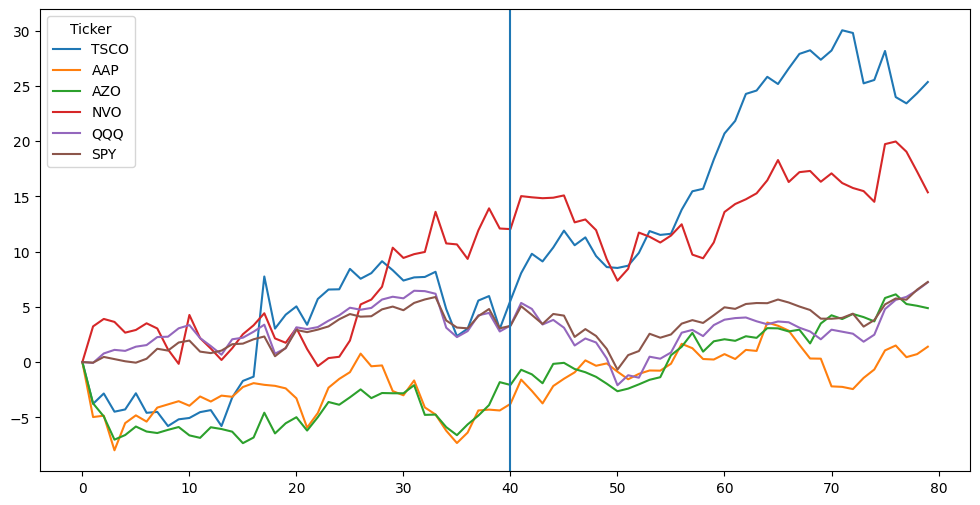

In [194]:
returns[returns.index < 80].plot(figsize=(12, 6))
plt.axvline(x=40)

In [227]:
returns.drop(columns=['QQQ', 'SPY']).mean(axis=1)


0         0.000000
1        -2.317380
2        -2.178813
3        -3.966572
4        -3.439761
           ...    
3807    722.781167
3808    700.232213
3809    694.533706
3810    707.523557
3811    723.048601
Length: 3812, dtype: float64

In [225]:
returns

Ticker,TSCO,AAP,AZO,NVO,QQQ,SPY
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-3.780441,-4.977096,-3.740689,3.228704,-0.072285,-0.055097
2,-2.845498,-4.854976,-4.918032,3.903253,0.777472,0.464383
3,-4.491825,-7.984749,-7.023097,3.633385,1.102878,0.267606
4,-4.288608,-5.526731,-6.605811,2.662107,1.012500,0.070868
...,...,...,...,...,...,...
3807,1218.838655,-4.995951,1309.992551,367.289411,1152.980779,607.202104
3808,1181.702219,-10.896166,1268.040295,362.082502,1171.140514,613.169671
3809,1167.095217,-8.140374,1263.636395,355.543588,1155.804701,609.208437
3810,1183.435245,-6.073536,1299.247453,353.485066,1151.785211,605.802840
